In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("PHASE 3: MODEL TRAINING AND EVALUATION")
print("="*60)

PHASE 3: MODEL TRAINING AND EVALUATION


In [2]:
# Load and preprocess data
print("\n1. LOADING AND PREPROCESSING DATA...")
df = pd.read_csv('data/European_Bank.csv')
df = df.drop(['CustomerId', 'Surname'], axis=1)
print(f"Shape after dropping IDs: {df.shape}")


1. LOADING AND PREPROCESSING DATA...
Shape after dropping IDs: (10000, 12)


In [3]:
# Create derived features
df['Balance_to_Salary'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['Balance_to_Salary'] = df['Balance_to_Salary'].clip(0, 5)
df['Age_Tenure'] = df['Age'] * df['Tenure']
df['Product_Density'] = df['NumOfProducts'] / (df['Tenure'] + 1)
df['Product_Engagement'] = df['NumOfProducts'] * df['IsActiveMember']
df['Wealth_Index'] = df['Balance'] + (df['EstimatedSalary'] / 12)
df['Account_Utilization'] = df['Balance'] / (df['NumOfProducts'] + 1)
df['High_Value'] = ((df['Balance'] > 50000) | (df['EstimatedSalary'] > 100000)).astype(int)
df['Credit_Category'] = pd.cut(df['CreditScore'], bins=[0, 580, 670, 740, 850], 
                                labels=['Poor', 'Fair', 'Good', 'Excellent'])
print("Feature engineering complete!")

Feature engineering complete!


In [4]:
# Encode categorical variables
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
le = LabelEncoder()
df['Credit_Category'] = le.fit_transform(df['Credit_Category'])
print("Encoding complete!")

Encoding complete!


In [5]:
# Prepare features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Scale numerical features
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
                  'EstimatedSalary', 'Balance_to_Salary', 'Age_Tenure',
                  'Product_Density', 'Product_Engagement', 'Wealth_Index',
                  'Account_Utilization']
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
print(f"Features shape: {X.shape}")

Features shape: (10000, 20)


In [6]:
# Split data
print("\n2. SPLITTING DATA...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Testing set:  {X_test.shape[0]} samples")


2. SPLITTING DATA...
   Training set: 8000 samples
   Testing set:  2000 samples


In [7]:
# Define and train models
print("\n3. TRAINING MODELS...")
print("-" * 50)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    print(f"\n   Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
    
    print(f"      Accuracy: {results[-1]['Accuracy']:.4f}")
    print(f"      ROC-AUC:  {results[-1]['ROC-AUC']:.4f}")


3. TRAINING MODELS...
--------------------------------------------------

   Training Logistic Regression...
      Accuracy: 0.8080
      ROC-AUC:  0.7738

   Training Decision Tree...
      Accuracy: 0.7930
      ROC-AUC:  0.6935

   Training Random Forest...
      Accuracy: 0.8620
      ROC-AUC:  0.8510

   Training Gradient Boosting...
      Accuracy: 0.8670
      ROC-AUC:  0.8686


In [8]:
# Display results
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

best_idx = results_df['ROC-AUC'].idxmax()
print(f"\n🏆 BEST MODEL: {results_df.loc[best_idx, 'Model']} (ROC-AUC: {results_df.loc[best_idx, 'ROC-AUC']:.4f})")


MODEL PERFORMANCE SUMMARY
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression     0.808   0.586466 0.191646  0.288889 0.773823
      Decision Tree     0.793   0.491954 0.525799  0.508314 0.693533
      Random Forest     0.862   0.767347 0.461916  0.576687 0.850974
  Gradient Boosting     0.867   0.783133 0.479115  0.594512 0.868594

🏆 BEST MODEL: Gradient Boosting (ROC-AUC: 0.8686)


In [9]:
# Feature importance
print("\n4. FEATURE IMPORTANCE ANALYSIS...")
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n   Top 10 Most Important Features:")
for i, row in feature_importance.head(10).iterrows():
    print(f"      {row['feature']:<25} {row['importance']:.4f}")

# Save results
feature_importance.to_csv('feature_importance_rf.csv', index=False)
results_df.to_csv('model_comparison.csv', index=False)
print("\n✓ Results saved to CSV files")


4. FEATURE IMPORTANCE ANALYSIS...

   Top 10 Most Important Features:
      Age                       0.1771
      NumOfProducts             0.0925
      Wealth_Index              0.0876
      CreditScore               0.0772
      Age_Tenure                0.0763
      EstimatedSalary           0.0757
      Account_Utilization       0.0656
      Balance                   0.0619
      Balance_to_Salary         0.0545
      Product_Density           0.0432

✓ Results saved to CSV files



5. GENERATING VISUALIZATIONS...


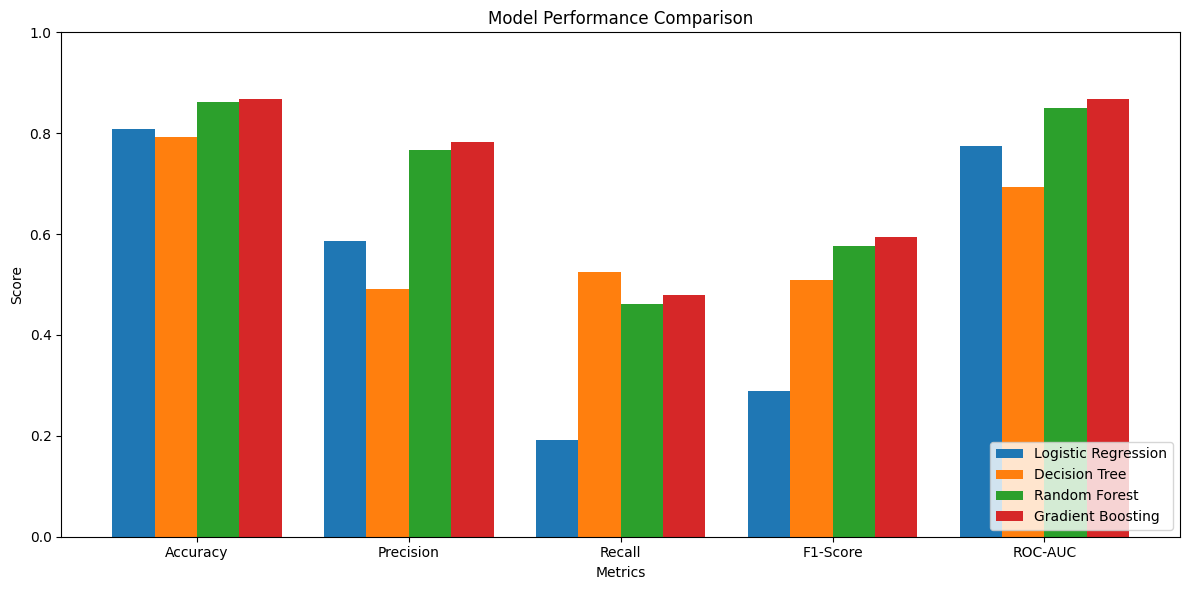

✓ Figure saved: 05_model_comparison.png


In [10]:
# Figure 1: Model Comparison
print("\n5. GENERATING VISUALIZATIONS...")

fig, ax = plt.subplots(figsize=(12, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2

for i, (idx, row) in enumerate(results_df.iterrows()):
    values = [row[m] for m in metrics]
    ax.bar(x + i*width, values, width, label=row['Model'])

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('figures/05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: 05_model_comparison.png")

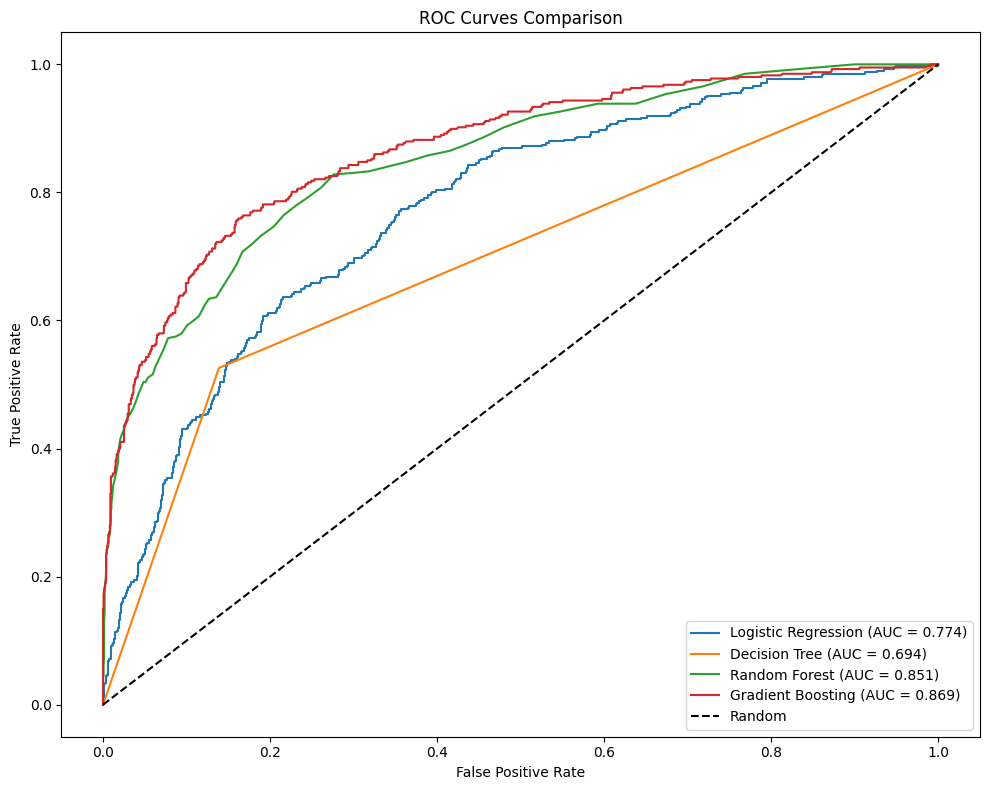

✓ Figure saved: 06_roc_curves.png


In [11]:
# Figure 2: ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('figures/06_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: 06_roc_curves.png")

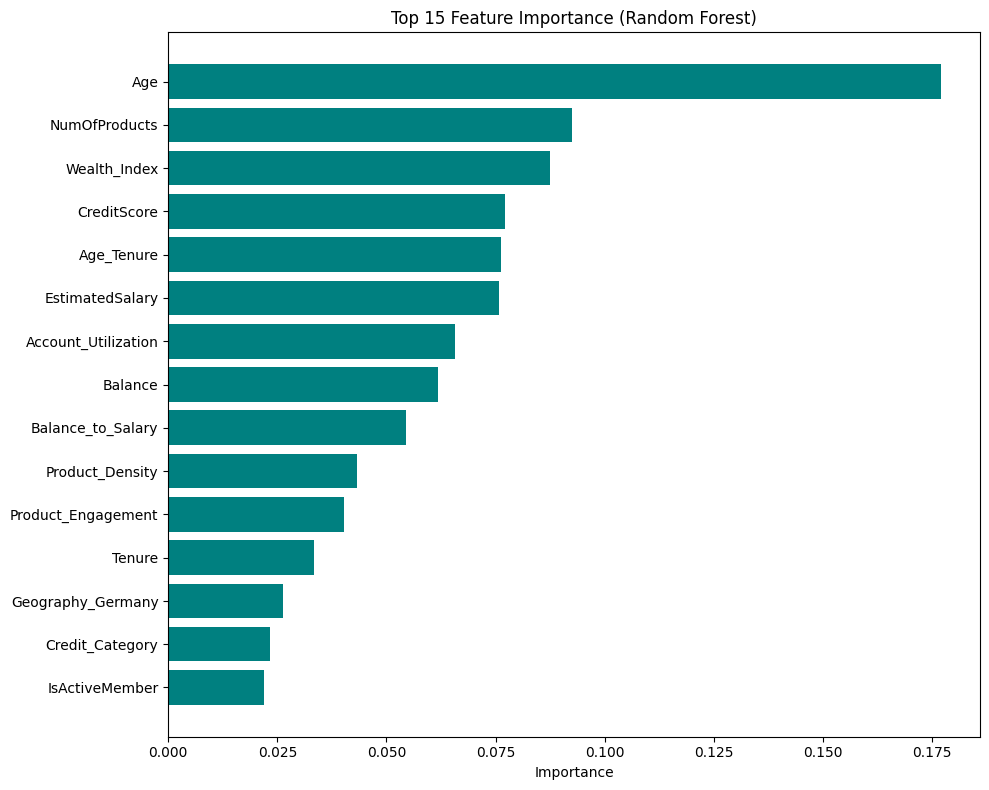

✓ Figure saved: 08_feature_importance.png


In [12]:
# Figure 3: Feature Importance
fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance.head(15)
ax.barh(top_features['feature'], top_features['importance'], color='teal')
ax.set_xlabel('Importance')
ax.set_title('Top 15 Feature Importance (Random Forest)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: 08_feature_importance.png")

In [13]:
print("\n" + "="*60)
print("PHASE 3 COMPLETE!")
print("="*60)


PHASE 3 COMPLETE!
